# Latent Dirichlet Allocation - Introduction
1. Each Document is a collection of topics
2. Each Topic is a collection of words

# Conceptual reason why LDA uses a Dirichlet Distribution
1. Assumption-1: each topic is a Dirichlet R.V. of the words present in the corpus
    1. words present in the corpus = list of all unique words found across all documents in the *training* corpus
    2. $k^{th}$ topic = $\sum\limits_{w \epsilon W} p_{w,k}$.w, s.t. $\sum\limits_{w \epsilon W}p_{k, w} = 1 \, ,\, \forall \,   k \,  \epsilon \,  [1,2,\cdots K]$ , where W: vocabulary(set of all words), w: $w^{th}$ word
    3. hence, each topic can be represented by a $W$ dimensional vector with all components being probability parameters.
    4. $k: [p_{1, k}, p_{2, k}, \cdots , p_{W, k}]$ is the dirichlet-distributed random vector.
    5. a topic: probability distribution over all words of the corpus.
2. Assumption-2: each document is a Dirichlet R.V. of the topics found from the first assumption
    1. $d^{th}$ document = $\sum\limits_{k \epsilon {1,2,\cdots ,K}} p_{k,d}$.k, s.t. $\sum\limits_{k \epsilon {1,2,\cdots ,K}}p_{k, d} = 1 \, ,\, \forall \,   d \,  \epsilon \,  [1,2,\cdots D]$ , where D: set of all documents used, k: $k^{th}$ topic
    2. hence, each document is represented by a $K$ dimensional vector with all components being probability parameters.
    3. $d: [p_{d, 1}, p_{d, 2}, \cdots , p_{d, K}]$ is the dirichlet-distributed random vector.
    4. a document: probability distribution over all topics modelled.

# Algorithm that uses Gibbs Sampling for learning hidden topic assignments
1. tokenize each document $d$
2. initialise the 3 hyperparameters: $\alpha, \beta, K$
    1. $K:$ total no. of topics to be modelled
    2. $\alpha: \alpha_{K\times 1}$  is the document-topic dirichlet prior concentration parameter vector.
    3. $\beta: \beta_{V\times 1}$  is the topic-word dirichlet prior concentration parameter vector.
    4. here, $V$: is the vocabulary size, i.e. the set of distinct tokens across all documents in the *training* corpus
2. for each document $d$, randomly assign each token of the token-sequence to one of the topics : $\{1,2,\cdots K\}$
    1. usually, a discrete uniform distribution is used, where $x = \{1,2,\cdots K\}$ all have a probability of $\dfrac{1}{K}$ rest all values have probability = 0.
    2. evaluate and store the following quantities:
        1. $n_{d,k}$: no. of tokens(token-occurences) in document $d$ that have been assigned to topic $k$.
        2. $N_d$: total no. of tokens(token-occurences) in document $d$.
        3. $n_{k, w}$: no. of times **across all documents** the token(token-occurence) $w$ is assigned to the topic $k$.
        4. $n_{k} = \sum\limits_{w \,\epsilon\, V}n_{k,w}$: total no. of tokens(token-occurences) assigned to topic $k$.
        5. the matrix $\phi: \begin{bmatrix}\phi_{1, 1} & \phi_{1, 2} & \cdots & \phi_{1, V} \\ \phi_{2, 1} & \phi_{2, 2} & \cdots & \phi_{2, V} \\ & & \vdots & \\ \phi_{K, 1} & \phi_{K, 2} & \cdots & \phi_{K, V} \end{bmatrix}$, where $\phi_{k, w} = \dfrac{n_{k, w} + \beta_w}{n_k + \sum\limits_{w \,\epsilon\, V}\beta_w}$ is the probability of the $w^{th}$ token to belong to the $k^{th}$ topic.
        6. the matrix $\theta: \begin{bmatrix}\theta_{1, 1} & \theta_{1, 2} & \cdots & \theta_{1, K} \\ \theta_{2, 1} & \theta_{2, 2} & \cdots & \theta_{2, K} \\ & & \vdots & \\ \theta_{D, 1} & \theta_{D, 2} & \cdots & \theta_{D, K} \end{bmatrix}$, where $\theta_{k, w} = \dfrac{n_{d, k}}{N_d  + \sum\limits_{k=1}^K \alpha_k}$ is the probability of the $d^{th}$ document belonging to the $k^{th}$ topic.
3. perform step 5 for some number of iterations, or till [convergence](#lda_convergence) is reached
4. for each document $d$, iterate through each of the tokens in its token-sequence and do the following
    1. for the current occurrence of token $w$, remove the topic assignment.
    2. update all affected quantities: $n_{d, k}\rightarrow {n^{-di}_{d,k}} \,,\, n_{k, w}\rightarrow n_{k, w}^{-di} \,,\, n_{k}\rightarrow n_{k}^{-di} \quad \forall \,\, k \,\, \epsilon \, [1, 2, \cdots , K]$
    3. use this **Gibbs sampling** probability equation to update the probability of word $w$ being assigned with topic $k$ as:\
        $P(z_{di} = k | Z^{-di}, W, \beta, \alpha) \propto \left(n^{-di}_{d,k} + \alpha_k\right).\left(\dfrac{n_{k, w}^{-di} + \beta_w}{n_{k}^{-di} + \sum\limits_{w \,\epsilon\, V}\beta_w}\right)$ , where $z$ represents the topic assignment event of this token-occurrence, and $w|z = k$ represents that probability of assigning topic $k$ to token $w$.
    4. the first term reperesents the updated document-topic model probability term, and the second term represents the updated topic-word distribution.
    5. this term follows from the application of Bayes' theorem in the following style: $P(W|Z, \theta, \phi, \alpha, \beta) = P(W| Z , \phi).P(Z|\theta).P(\theta | \alpha).P(\phi | \beta)$
        1. first sample the dirichlet document-topic and topic-word priors $P(\theta | \alpha)$ and $P(\phi | \beta)$ respectively
        2. given these, now sample a set of topics stored in $Z$, which will be the term $P(Z | \theta)$
        3. now that you've topics sampled, start generating words/tokens that *define each sampled topic*. this is the $P(W | Z, \phi)$ term. Logically to do this you would need the set of topics ($Z$) and the topic-word distribution ($\phi$)
    6. implementationally, a temporary quantity called $tQ_{k, w}$ will be assigned to this product, for all the $K$ topics for the current token $w$\
    $P(z_{di} = k) \dfrac{tQ_{k, w}}{\sum\limits_{k=1}^K tQ_{k, w}}$
    7. hence, for the current token we have K probability values, which will be used to sample a new topic-assignment for this token(token-occurence in document $d$)
    8. after assigning a new topic, say the topic $k1$, update all scalar quantities(increment by 1): ${n^{-di}_{d,k1}}\rightarrow n_{d, k1}  \,,\, n_{k1, w}^{-di} \rightarrow n_{k1, w} \,,\, n_{k1}^{-di}\rightarrow n_{k1}$
    9. now update the topic-word and document-topic probability matrices as well: $\theta_{k, w} = \dfrac{n_{d, k}}{N_d} \,\,,\,\, \phi_{k, w} = \dfrac{n_{k, w}}{n_k}$ (new values of $n_{d, k}\,,\, n_{k, w}\,,\, n_k$)

# Key details of the algorithm
1. **Hyperparameters**: a lot depends on the initial choice of the concentration parameters and the value of $K$, i.e. no. of topics
2. $\alpha_k$ acts as a safety term if say no tokens of a given document $d$ are assigned to topic $k$, and same goes for the $\beta_w$ term.
3. common heuristic: $\alpha = \left[\cdots \dfrac{50}{K} \cdots\right]_{K\times 1} \quad , \quad \beta = \left[\cdots 0.01 \cdots\right]_{V\times 1}$
4. the reason why the document-topic term is not normalized is because the sum over all topics of that expression is equal to $N_d + ||\alpha||_1$, which is a constant term, hence doesn't need to be actually computed.
5. also, the initial random assignment of topics also plays a key role, i.e. step-3.

# Convergence<a name="lda_convergence"></a>
1. Even if this is an unsupervised algorithm, good implementation usually keeps a hold out test set of documents.
2. the main *thing to be trained* are the document-topic and topic-word distribution matrices, i.e. $\phi \,,\, \theta$
3. after the $t^{th}$ iteration, we can check any of the following terms to determine convergence
    1. **Frobenius norm**: The L2-norm but of a matrix: $||\phi^{t} - \phi^{t-1}||_F = \sqrt{\sum\limits_{k=1}^K\sum\limits_{w \,\epsilon\, V} \left(\phi_{k, w}^{(t)} - \phi_{k, w}^{(t-1)} \right)^2} \quad , \quad ||\theta^{(t)} - \theta^{(t-1)}||_F = \sqrt{\sum\limits_{d=1}^D\sum\limits_{k=1}^K \left(\theta_{d, k}^{(t)} - \theta_{d, k}^{(t-1)} \right)^2}$
        1. should go down with further iterations
    2. **KL Divergence**: $D_{\phi^{(t)} \, , \, \phi^{(t-1)}} = \sum\limits_{k=1}^K\sum\limits_{w \,\epsilon\, V} \phi_{k, w}^{(t)} log\left(\dfrac{\phi_{k, w}^{(t)}}{\phi_{k, w}^{(t-1)}}\right) \quad , \quad D_{\theta^{(t)} \, , \, \theta^{(t-1)}} = \sum\limits_{d=1}^D\sum\limits_{k=1}^K \theta_{d,k}^{(t)} log\left(\dfrac{\theta_{d,k}^{(t)}}{\theta_{d,k}^{(t-1)}}\right) $
        1. should approach 0, and deviating away from 0 is a problem.
    3. **Log likelihood**: $\sum\limits_{d=1}^D\sum\limits_{n=1}^{N_d} log\left(\sum\limits_{k=1}^K P(w|z, \theta, \phi) \right) = \sum\limits_{d=1}^D\sum\limits_{n=1}^{N_d} log\left(\sum\limits_{k=1}^K \phi_{k, w} \right)$
        1. for the best topic model, all $\phi_{k, w} = 1$ hence the log-likelihood tends to 0
        2. and usually, since $\phi_{k, w} < 1$ , the log-likelihood will always be positive.
        3. so the aim is to minimize this as much as possible.
    3. **Perplexity**: $exp\left(-\dfrac{1}{V}\sum\limits_{d=1}^D\sum\limits_{n=1}^{N_d}-log P(w_{d,n} | \theta, \phi)\right)$, where $P(w_{d, n} | \theta, \phi) = \sum\limits_{k=1}^K \theta_{d,k} \times \phi_{k, w}$
        1. best case: $P(w_{d,n}) = 1$, i.e. 0 perplexity
        2. perplexity should be as low as possible
4. if (any of these convergence metrics chosen) has a change less than the tolerance ($10^{-4}$), convergence has been attained.
5. **Fallacy**
    1. whatif the metric goes in a direction oppposite to the expected direction?
    2. implement the `patience` feature into the LDA implementation that stores the best-distributions until now and lets the current distributions($\theta, \phi$) turn bad till a certain no. of `patience` iterations after which the iterations are stopped.
6. Additionally, a train-set and test-set metric can be evaluated to know the overfitting nature of the current-distributions($\theta, \phi$). (for instance, perplexity using ($\theta, \phi$) on the training document corpus and perplexity of the held-out test-document corpus can be plotted per iterations to check for overfitting)
    1. <font color="red">Random thought: Probably the alpha or beta values could be changed mid algorithm to resolve overfitting. Lets discuss with GPT.</font>

In [2]:
import numpy as np
from scipy.stats import dirichlet

import matplotlib.pyplot as plt
import seaborn as sb

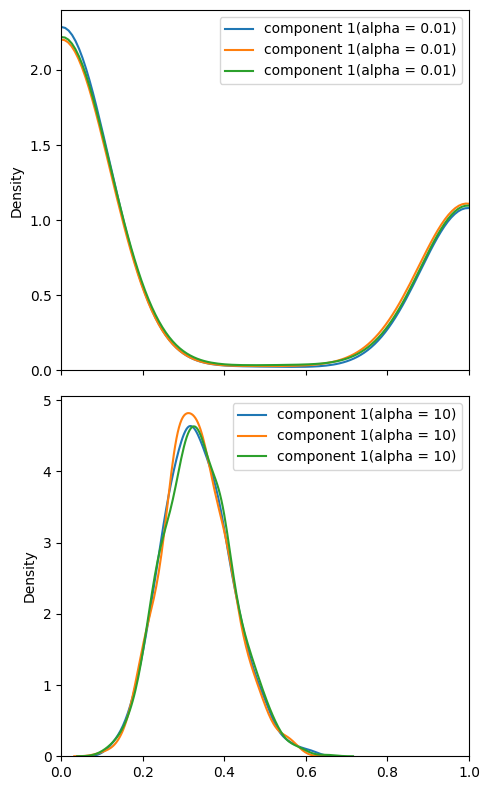

In [6]:
small_alpha, large_alpha = [0.01, 0.01, 0.01], [10, 10, 10]

small_alpha_dirichlet_gen = dirichlet(alpha=small_alpha, seed = 42)
large_alpha_dirichlet_gen = dirichlet(alpha=large_alpha, seed = 42)

small_alpha_dirichlet_vals = small_alpha_dirichlet_gen.rvs(size = 1000)
large_alpha_dirichlet_vals = large_alpha_dirichlet_gen.rvs(size = 1000)

fig, ax = plt.subplots(2, 1, sharex = True, figsize=(5, 8))

for component_idx, alpha_val in enumerate(small_alpha):
    sb.kdeplot(small_alpha_dirichlet_vals[:, component_idx], label = f'component 1(alpha = {alpha_val})', ax = ax[0])
ax[0].set_xlim([0, 1])
ax[0].legend()

for component_idx, alpha_val in enumerate(large_alpha):
    sb.kdeplot(large_alpha_dirichlet_vals[:, component_idx], label = f'component 1(alpha = {alpha_val})', ax = ax[1])
ax[1].legend()

plt.tight_layout()
plt.show()